In [3]:
import pandas as pd

failed_mols = pd.read_csv("hpc/data/failed_compounds.txt", header=None, names=["molecule_chembl_id"])
chembl_mols = pd.read_csv("data/DATASET_ic50_cleaned_compounds.csv")

In [9]:
failed_docking = pd.merge(chembl_mols, failed_mols, on=["molecule_chembl_id"])

In [10]:
failed_docking.head()

,smiles,molecule_chembl_id,pIC50,n_stereocenters,undefined_stereo
0,C=CCO[C@H]1CCN2C(=O)C(NC(=O)C(CCCN=C(N)N)NC(=O...,CHEMBL5203513,8.698970,17,True
1,C=CCO[C@H]1CCN2C(=O)C(NC(=O)C(CCCN=C(N)N)NC(=O...,CHEMBL5205422,9.000000,16,True
2,CC1CCN(CC2NC(=O)C(CCCN=C(N)N)NC(=O)C(Cc3ccccc3...,CHEMBL5201714,6.096910,13,True
3,CCCC1NC(=O)C(Cc2ccc(-c3ccccc3)cc2)NC(=O)C(CC(C...,CHEMBL5193586,6.218963,15,True
4,CCCCCC1NC(=O)C2CCCN2C(=O)C(CC(=O)O)NC(=O)C(Cc2...,CHEMBL5200027,8.301030,16,True


In [11]:
import datamol as dm

failed_docking["clean_mols"] = dm.parallelized(dm.to_mol, failed_docking["smiles"].values, n_jobs=-1)

/Users/jerlynlim/Documents/mscphm/sem2/5013/project/env_1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
from rdkit.Chem import rdMolDescriptors, Crippen, Lipinski, QED

def get_extended_descriptors(mol):
    """Function to calculate 8 descriptors for a single molecule."""
    if mol is None:
        return {col: None for col in ["MW", "ClogP", "TPSA", "HBD", "HBA", "QED", "FractionCsp3", "NumAromaticRings"]}
    
    return {
        "MW": rdMolDescriptors.CalcExactMolWt(mol),
        "ClogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "QED": QED.qed(mol),
        "FractionCsp3": rdMolDescriptors.CalcFractionCSP3(mol),
        "NumAromaticRings": Lipinski.NumAromaticRings(mol)
    }

# Run parallel processing on the column containing RDKit Mol objects
results = dm.parallelized(get_extended_descriptors, failed_docking["clean_mols"].values, n_jobs=-1)

In [18]:
desc_df = pd.DataFrame(results)
desc_df.isna().values.any()

False

In [19]:
df1 = failed_docking.reset_index(drop=True)
df2 = desc_df.reset_index(drop=True)

In [20]:
df = pd.concat([df1, df2], axis=1)

In [21]:
df["HBD_HBA"] = df["HBD"] + df["HBA"]
descriptors = ["MW", "ClogP", "TPSA", "HBD", "HBA", "QED", "FractionCsp3", "NumAromaticRings"]
print("Missing values per column:")
print(df[descriptors].isna().sum())

Missing values per column:
MW                  0
ClogP               0
TPSA                0
HBD                 0
HBA                 0
QED                 0
FractionCsp3        0
NumAromaticRings    0
dtype: int64


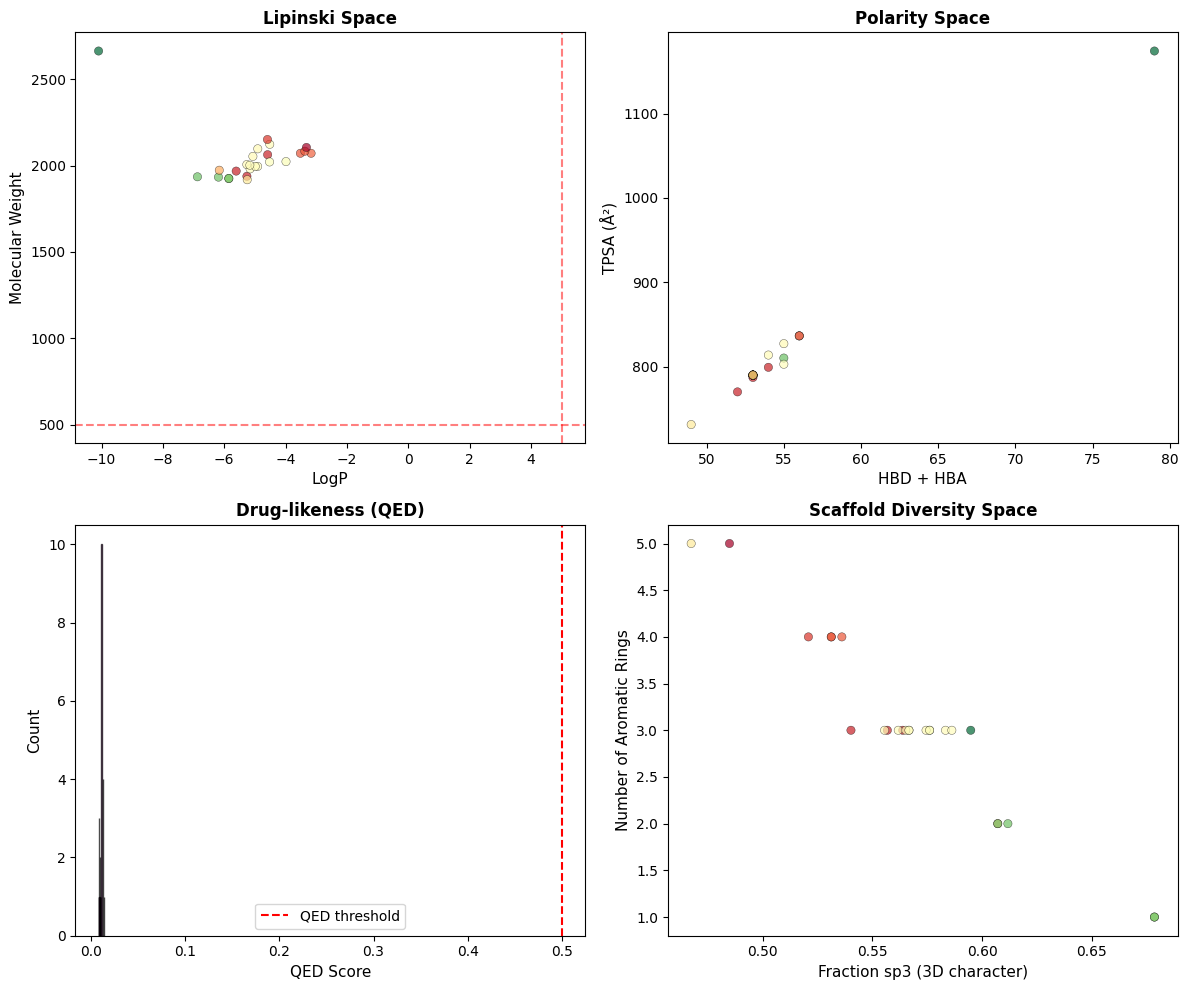

In [22]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# ============================================================
# CHEMICAL SPACE VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# MW vs LogP (Lipinski space)
ax1 = axes[0, 0]
scatter = ax1.scatter(df['ClogP'], df['MW'],
                      c=df['QED'],
                      cmap='RdYlGn',
                      alpha=0.7, edgecolor='k', linewidth=0.3)
ax1.axhline(y=500, color='red', linestyle='--', alpha=0.5, label='Lipinski MW')
ax1.axvline(x=5, color='red', linestyle='--', alpha=0.5, label='Lipinski LogP')
ax1.set_xlabel('LogP', fontsize=11)
ax1.set_ylabel('Molecular Weight', fontsize=11)
ax1.set_title('Lipinski Space', fontsize=12, fontweight='bold')

# TPSA vs HBD+HBA
ax2 = axes[0, 1]
df['HB_total'] = df['HBD'] + df['HBA']
scatter2 = ax2.scatter(df['HB_total'], df['TPSA'],
                        cmap='RdYlGn',
                        c=df['QED'],
                       alpha=0.7, edgecolor='k', linewidth=0.3)
ax2.set_xlabel('HBD + HBA', fontsize=11)
ax2.set_ylabel('TPSA (Å²)', fontsize=11)
ax2.set_title('Polarity Space', fontsize=12, fontweight='bold')

# QED distribution
ax3 = axes[1, 0]
ax3.hist(df['QED'], bins=25, edgecolor='black', alpha=0.7, color='purple')
ax3.axvline(x=0.5, color='red', linestyle='--', label='QED threshold')
ax3.set_xlabel('QED Score', fontsize=11)
ax3.set_ylabel('Count', fontsize=11)
ax3.set_title('Drug-likeness (QED)', fontsize=12, fontweight='bold')
ax3.legend()

ax4 = axes[1, 1]  # e.g., bottom-right panel

scatter = ax4.scatter(df['FractionCsp3'],
                      df['NumAromaticRings'],
                      c=df['QED'],
                      cmap='RdYlGn',
                      alpha=0.7, edgecolor='k', linewidth=0.3)

ax4.set_xlabel('Fraction sp3 (3D character)', fontsize=11)
ax4.set_ylabel('Number of Aromatic Rings', fontsize=11)
ax4.set_title('Scaffold Diversity Space', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/failed_docking_chemical_space.png', dpi=300, bbox_inches='tight')
plt.show()